In [1]:
from fontTools.misc.textTools import tostr
!ls

CentralLimitTheorem.ipynb  InverseTransformSampling.ipynb


In [2]:
!pwd

/home/svu/e1554287/projects/ideal-ML-train/math-illustrations


In [2]:
# filepath: clt_visualizer.py
"""
Central Limit Theorem Visualizer (Plotly + SciPy)

Usage (in Jupyter):
-------------------
from clt_visualizer import list_distributions, visualize_clt

list_distributions()

# Example: standard normal as source
visualize_clt(distribution="norm", x1=30, x2=50, dist_params={"loc": 0, "scale": 1})

# Example: uniform(0,1) as source
visualize_clt(distribution="uniform", x1=40, x2=80, dist_params={"loc": 0, "scale": 1})
"""

'\nCentral Limit Theorem Visualizer (Plotly + SciPy)\n\nUsage (in Jupyter):\n-------------------\nfrom clt_visualizer import list_distributions, visualize_clt\n\nlist_distributions()\n\n# Example: standard normal as source\nvisualize_clt(distribution="norm", x1=30, x2=50, dist_params={"loc": 0, "scale": 1})\n\n# Example: uniform(0,1) as source\nvisualize_clt(distribution="uniform", x1=40, x2=80, dist_params={"loc": 0, "scale": 1})\n'

In [3]:
from __future__ import annotations #Enables postponed evaluation of type hints (annotations) for improved speed and compatibility in Python 3.7+

import time #time-related functions; here, for delays
from typing import Dict, Iterable, Optional, Tuple #advanced type hinting tools for static analysis, code clarity, and editor support

import numpy as np
from scipy import stats #statistical functions and distributions from the SciPy library 
import plotly.graph_objects as go #Plotly's interactive plotting tools for complex charts and graphs
from plotly.subplots import make_subplots #creation of multi-plot figures (multiple charts in one window) using Plotly

In [4]:
from tqdm.auto import tqdm  # auto picks notebook/terminal renderer

In [5]:
# Plotly's input/output utilities to control rendering, file export, and interactive options
import plotly.io as pio
pio.renderers.default = "notebook_connected"  # or "jupyterlab" / "vscode"
# pio.renderers.default = "png"  # uses kaleido server-side (no heavy JSON to laptop)

In [6]:
import io #Python's in-memory file handling functions, useful for buffers and file-like objects
import imageio.v2 as imageio #utilities for reading and writing image files in various formats
import ipywidgets #interactive widgets (sliders, buttons, etc.) for Jupyter and notebook-based GUIs
import matplotlib.pyplot as plt #for static charts

In [7]:
# Jupyter live-update (why: smooth animation without stacking multiple figures)
try:
    from IPython.display import display, clear_output #Using them together enables smooth animations by updating the same notebook output cell repeatedly, instead of stacking many new figures below each other.
    _HAS_IPY = True
except Exception:
    _HAS_IPY = False
    display = print
    def clear_output(wait: bool = True):
        pass

In [8]:
# -----------------------------
# Distribution catalog (curated)
# -----------------------------
# Why curated: SciPy doesn't expose a stable public "all continuous dists" list;
# we provide common continuous distributions that work well for CLT demos.
# loc - central location of dist on x axis; effectively "mean"
# scale -  stretches or compresses the dist; effectively "standard deviation" or spread
# s	- Spread of log of variable i.e. log-stddev (lognorm standard deviation)
# a - Gamma - Shape controlling skewness and spread
# b - pareto - Shape i.e. tail heaviness (tail index)
# a & b - Beta - represent the intensity/weight of "successes"/"failures" respectively - together define shape
# c - weibull_min, weibull_max - Shape of failure rate/curve (curve form)
# df - chi2, t - Degrees of freedom
AVAILABLE_DISTS: Dict[str, object] = {
    "norm": stats.norm,                # loc, scale
    "uniform": stats.uniform,          # loc, scale
    "expon": stats.expon,              # loc, scale
    "gamma": stats.gamma,              # a, loc, scale
    "beta": stats.beta,                # a, b, loc, scale
    "chi2": stats.chi2,                # df, loc, scale
    "lognorm": stats.lognorm,          # s, loc, scale
    "t": stats.t,                      # df, loc, scale
    "pareto": stats.pareto,            # b, loc, scale
    "weibull_min": stats.weibull_min,  # c, loc, scale
    "weibull_max": stats.weibull_max,  # c, loc, scale
    "cauchy": stats.cauchy,            # loc, scale (Cauchy has heavy tails, need to address)
    "laplace": stats.laplace,          # loc, scale
}

In [9]:
print(type(stats.norm))

<class 'scipy.stats._continuous_distns.norm_gen'>


In [9]:
def list_distributions(return_list: bool = False) -> Optional[Iterable[str]]:
#equivalent declaration of return type (python 3.10+):
# def list_distributions(return_list: bool = False) -> Iterable[str] | None:
    """
    Helper function - Show supported continuous distributions (SciPy names).
    """
    names = sorted(AVAILABLE_DISTS.keys()) #get all dist names and sort alphabetically
    print("Choose from following available continuous distributions:\n - " + "\n - ".join(names)) #Prints a user-readable list of distribution names, each prefixed with " - " and separated by new lines.
    if return_list: #provide option for function caller to get the list returned additionally
        return names
    return None

In [10]:
# -----------------------------
# Helper functions
# Python best practises and naming conventions: a leading underscore in a function or variable name ==>
# > "this is intended for internal use only; not part of the public API"
# > signals that these functions are helpers, not meant to be called directly from outside the module.
# > it doesn't enforce privacy, but it helps organize code and avoid accidental use.
# -----------------------------

In [29]:
from scipy.stats._distn_infrastructure import rv_generic
def _resolve_dist(name: str):
    # return frozen distributions available (e.g., stats.norm) or raise.
    if name not in AVAILABLE_DISTS:
        raise ValueError(
            f"Unknown distribution '{name}'. Call list_distributions() to see options."
        )
    return AVAILABLE_DISTS[name]

def _default_params_for(name: str) -> Dict[str, float]:
    # Minimal sensible defaults to avoid parameter errors across dists.
    if name == "norm":
        return {"loc": 0.0, "scale": 1.0}
    if name == "uniform":
        return {"loc": 0.0, "scale": 1.0}
    if name == "expon":
        return {"loc": 0.0, "scale": 1.0}
    if name == "gamma":
        return {"a": 2.0, "loc": 0.0, "scale": 1.0}
    if name == "beta":
        return {"a": 2.0, "b": 5.0, "loc": 0.0, "scale": 1.0}
    if name == "chi2":
        return {"df": 4.0, "loc": 0.0, "scale": 1.0}
    if name == "lognorm":
        return {"s": 0.5, "loc": 0.0, "scale": 1.0}
    if name == "t":
        return {"df": 5.0, "loc": 0.0, "scale": 1.0}
    if name == "pareto":
        return {"b": 3.0, "loc": 0.0, "scale": 1.0}
    if name == "weibull_min":
        return {"c": 1.5, "loc": 0.0, "scale": 1.0}
    if name == "weibull_max":
        return {"c": 1.5, "loc": 0.0, "scale": 1.0}
    if name == "cauchy":
        return {"loc": 0.0, "scale": 1.0}
    if name == "laplace":
        return {"loc": 0.0, "scale": 1.0}
    return {}

def _dist_range(distr_obj: rv_generic, params: Dict[str, float]) -> Tuple[float, float]:
    # robust x-range via ppf([0.001, 0.999]) with fallbacks to help plot the distribution
    # ppf ==> Percent Point Function (aka the inverse CDF or quantile function).
    # Why: keeps plots stable even for heavy-tailed distributions.
    try:
        # In SciPy, every distribution object (like scipy.stats.norm, scipy.stats.cauchy, etc.) has a .ppf() method
        lo = distr_obj.ppf(0.001, **params) # '**' syntax unpacks the params dictionary so each key-value pair is passed as a keyword argument to ppf.
        hi = distr_obj.ppf(0.999, **params)
        if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
            raise Exception
        return float(lo), float(hi)
    except Exception:
        # we fallback if PPF misbehaves (e.g., Cauchy, t, Pareto are heavy-tailed i.e. higher prob of extreme values -- even inf or nan -- which can break plots)
        name = getattr(distr_obj, "name", "unknown")
        if name == "cauchy":
            return -25.0, 25.0
        if name == "t":
            return -15.0, 15.0
        if name == "pareto":
            return 0.0, 10.0
        # Generic fallback
        return -10.0, 10.0

def _sample(distr_obj: rv_generic, numofsamples: int, params: Dict[str, float], rng: np.random.Generator) -> np.ndarray: #ndarray "N-dimensional array" is the core data structure in NumPy
    #draw 'numofsamples' num of samples (rvs ==> random variates samples).
    #rng is a np random number generator object pre-seeded with an integer; using rng as seed ensures custom randomness
    #NOTE: rvs can accept an integer for random_state as well but then would seed a new rand generator internally, so instead we pass the Generator object for full control over the random stream | reproducibility | avoiding interference with global random state
    return distr_obj.rvs(size=numofsamples, random_state=rng, **params) # '**' - flexible way to handle different distributions with different parameter requirements

def _pdf_grid(distr_obj: rv_generic, params: Dict[str, float], grid: np.ndarray) -> np.ndarray:
    # Computes the probability density function (PDF) values of the distribution at each point in grid
    return distr_obj.pdf(grid, **params)

def _hist_xy(data: np.ndarray, bins: int, density: bool = True) -> Tuple[np.ndarray, np.ndarray, np.ndarray]: #return set of 2 np arrays
    # return (bin_centers, heights, widths) for consistent plotting.
    # density=True ensures the area under the histogram will be 1 -- allows us to compare the hist shape directly to a theoretical pdf (with AUC=1) -- heights integrate to 1
    heights, edges = np.histogram(data, bins=bins, density=density) #np function; computes histogram and returns edges of bins+num of data points in each bin
    #num of edges is one higher than num of counts (i.e. num of bins)
    #[:-1] ==> "all elements except the last"; [1:] ==> "all elements except the first"
    #then pair up the adjacent edge coordinates and calculate their centroid
    centers = (edges[:-1] + edges[1:]) / 2.0
    widths = edges[1:] - edges[:-1]
    return centers, heights, widths

# Use a data-driven bin count for final histogram (Freedman–Diaconis -- balances resolution/detail vs noise)
# We dont use this during the loop to avoid flicker and bars jumping around
def _fd_bins(data: np.ndarray, *, min_bins: int = 5, max_bins: int = 80) -> int:
    # h = 2 * IQR(data) * numOfSamples^(-1/3) = FD bin width
    # IQR = 75th Quartile - 25th Quartile -- robust to outliers since ignores std
    # Theory: n^(-1/3) term comes from minimizing the asymptotic mean integrated squared error of the histogram as a density estimator.
    x = np.asarray(data)
    xlen = len(x)
    #if just 1 datapoint OR all values almost the same, return min_bins
    if xlen < 2 or np.allclose(x.min(), x.max()):
        return min_bins
    #'*' is unpacking operator, unpacks the two outputs [75th percentile, 25th percentile] so they can be subtracted
    iqr = np.subtract(*np.percentile(x, [75, 25])) #equivalent to p.percentile(x, 75) - np.percentile(x, 25)
    iqr = max(iqr, 1e-12) #avoid zero or infinitesimal - cases where data almost all similar
    h = 2 * iqr * (xlen ** (-1/3) + 1e-9)
    h = max(h, 1e-12) #avoid zero
    # number of bins ≈ (max x - min x)/h
    numbins = int(np.ceil((x.max() - x.min()) / h))
    return int(np.clip(numbins, min_bins, max_bins)) #ensure result within the bounds

def _fit_poly_curve(x: np.ndarray, y: np.ndarray, deg: int = 2, num: int = 400) -> Tuple[np.ndarray, np.ndarray]:
    # fit polynomial on data (x,y)
    # Why poly: a simple, stable regression to show smooth "model fit" through histogram tops.
    coeffs = np.polyfit(x, y, deg=deg) #numpy's function to find coeffs of best fit
    xx = np.linspace(float(x.min()), float(x.max()), num=num) #evenly spaced x-axis points for smooth plotting
    yy = np.polyval(coeffs, xx) #use fitted polynomial and get predicted values
    # yy = np.clip(yy, a_min=0, a_max=None) #remove all negative y values if only want to show above y=0
    return xx, yy #returns a smooth set of points for plotting.

# This function helps to scale the normal PDF to a count-based histogram in case it is not density based
def _return_normal_pdf(mu: float, sigma: float, xgrid: np.ndarray, scale: float | None = None) -> np.ndarray:
    # given pre-calculated mean/variance, returns normal pdf on xgrid scaled to histogram counts.
    if sigma <= 0 or not np.isfinite(sigma):
        return np.zeros_like(xgrid)
    pdf = stats.norm.pdf(xgrid, loc=mu, scale=sigma)
    # Scale PDF to comparable area/height as the histogram: multiply by bin width * total count
    # Caller must pass appropriate scale (e.g., total_count * bin_width)
    # We assume in the default case, user's histogram is density based and hence they didn't pass a scale
    return (pdf * scale) if scale else pdf

In [12]:
# -----------------------------
# Main visualization
# -----------------------------
"""
    Visualize the Central Limit Theorem with iterative sampling and live charts.

    Parameters
    ----------
    distribution : str
        Name from list_distributions() -- choose which dist to sample from
    x1 : int
        num of Samples per iteration i.e. size of sample group (default 30).
    x2 : int
        Number of iterations i.e. how many samles to compute (default 50).
    dist_params : dict or None
        Parameters for the chosen SciPy distribution (e.g., {"loc":0,"scale":1}).
    bins : int
        Histogram bins for sample means.
    pause_s : float
        Seconds to pause between iterations (animation speed).
    random_state : int or None
        Seed for reproducibility.
    poly_degree : int
        Degree for polynomial regression fit through histogram tops.

    Returns
    -------
    dict with keys: {"final_means", "chart2_histogram", "chart3_regression", "chart4_normal"}
    """


'\n    Visualize the Central Limit Theorem with iterative sampling and live charts.\n\n    Parameters\n    ----------\n    distribution : str\n        Name from list_distributions() -- choose which dist to sample from\n    x1 : int\n        num of Samples per iteration i.e. size of sample group (default 30).\n    x2 : int\n        Number of iterations i.e. how many samles to compute (default 50).\n    dist_params : dict or None\n        Parameters for the chosen SciPy distribution (e.g., {"loc":0,"scale":1}).\n    bins : int\n        Histogram bins for sample means.\n    pause_s : float\n        Seconds to pause between iterations (animation speed).\n    random_state : int or None\n        Seed for reproducibility.\n    poly_degree : int\n        Degree for polynomial regression fit through histogram tops.\n\n    Returns\n    -------\n    dict with keys: {"final_means", "chart2_histogram", "chart3_regression", "chart4_normal"}\n    '

In [41]:
distribution_name: str = "norm"
x1: int = 40
x2: int = 160
dist_params: Optional[Dict[str, float]] = None
capture_gif_path: str | None = "../artifacts/clt.gif"
bins: int = 20
pause_s: float = 0.1
random_state: Optional[int] = None
poly_degree: int = 4
show_every: int = 5  # display the matplotlib figure every k iterations (<=0 to disable)

In [26]:
if x1 <= 0 or x2 <= 0:
    raise ValueError("x1 and x2 must be positive integers.")
dist_obj = _resolve_dist(distribution_name) #get the scipy distribution object
params = _default_params_for(distribution_name) #get default params
if dist_params:
    params.update(dist_params)  # override defaults with user-specified if available
random_state=645
rng = np.random.default_rng(random_state)

# Prepare continuous PDF grid
lo, hi = _dist_range(dist_obj, params)
xgrid_pdf = np.linspace(lo, hi, 600) #600 evenly spaced values between lo and hi (the range of the distribution); used as the x-axis for plotting the PDF.
ygrid_pdf = _pdf_grid(dist_obj, params, xgrid_pdf) #pdf values at each point in xgrid; used as y-values for plotting the PDF

Sampling & updating:   0%|          | 0/160 [00:00<?, ?it/s]

Update at iteration: 4


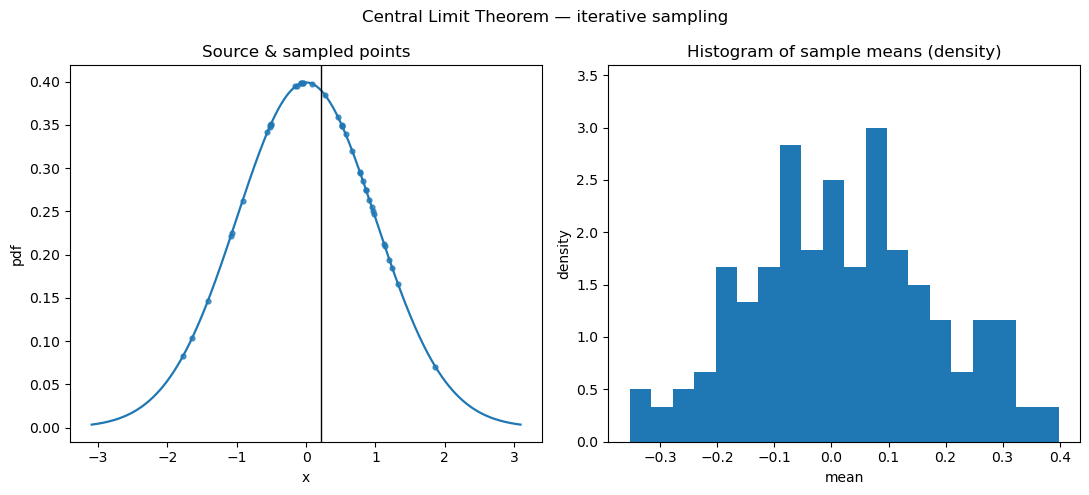

Update at iteration: 9
Update at iteration: 14
Update at iteration: 19
Update at iteration: 24
Update at iteration: 29
Update at iteration: 34
Update at iteration: 39
Update at iteration: 44
Update at iteration: 49
Update at iteration: 54
Update at iteration: 59
Update at iteration: 64
Update at iteration: 69
Update at iteration: 74
Update at iteration: 79
Update at iteration: 84
Update at iteration: 89
Update at iteration: 94
Update at iteration: 99
Update at iteration: 104
Update at iteration: 109
Update at iteration: 114
Update at iteration: 119
Update at iteration: 124
Update at iteration: 129
Update at iteration: 134
Update at iteration: 139
Update at iteration: 144
Update at iteration: 149
Update at iteration: 154
Update at iteration: 159


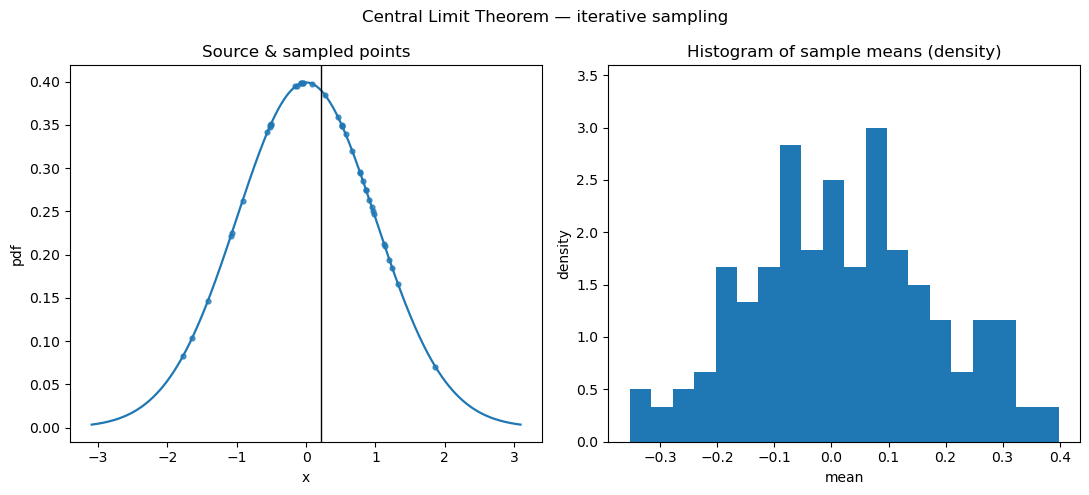

In [27]:
# frame buffer for making GIF
_frames = [] if capture_gif_path else None  # store plot frames in buffer if capture_gif_path is set
means: list[float] = [] # placeholder set of means (start empty, grows each iteration)

# --- CHART 1: Matplotlib two-panel (PDF + samples) and density histogram of sample means ---
# Batched live updates; server-side frame capture only.
preview_handle = None  # persistent display handle for mfig
# tqdm progress bar 
pbar = tqdm(total=x2, desc="Sampling & updating", leave=False, dynamic_ncols=True)
for _ in range(x2): #run the loop "x2" times
    # Draw 'x1' samples → compute mean → append to means.
    samples = _sample(dist_obj, x1, params, rng)
    m = float(np.mean(samples))
    means.append(m)

    # density histogram of means so far
    centers, dens, widths = _hist_xy(np.asarray(means), bins=bins, density=True)

    # build a lightweight two-panel Matplotlib figure for this iteration
    plt.close('all')
    mfig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 5)) # second output is "axes" -- mapped to left and right in place
    mfig.suptitle("Central Limit Theorem — iterative sampling")

    # Update left subplot
    # Left: source PDF + sampled points positioned at pdf height + current mean line
    # Cosmetic: for y-axis, We compute approximate pdf values at sample x for vertical positioning on pdf baseline; (y=0 for markers would be misleading; we place at pdf for visual context)
    ax_left.plot(xgrid_pdf, ygrid_pdf, linewidth=1.6)
    ax_left.scatter(samples, _pdf_grid(dist_obj, params, samples), s=12, alpha=0.75)
    ax_left.axvline(m, color='k', linewidth=1)  # why: highlight current mean with vertical line
    ax_left.set_title("Source & sampled points")
    ax_left.set_xlabel("x")
    ax_left.set_ylabel("pdf")

    # Update right subplot histogram of means
    # Right: density histogram of sample means so far
    ax_right.bar(centers, dens, width=widths, align="center")
    ax_right.set_title("Histogram of sample means (density)")
    ax_right.set_xlabel("mean")
    ax_right.set_ylabel("density")
    if len(dens):
        ax_right.set_ylim(0, max(dens) * 1.2)

    mfig.tight_layout()
    # display(mfig)

    # Conditional on-Notebook preview every k iterations
    if _HAS_IPY and show_every and show_every > 0 and ((_ + 1) % show_every == 0 or (_ + 1) == x2):
        print("Update at iteration: " + str(_))
        # refresh the single output cell instead of spamming
        if preview_handle is None:
            # first time: create handle
            preview_handle = display(mfig, display_id=True)
        else:
            # subsequent previews: update same output
            preview_handle.update(mfig)
        # ** another way **, use a post-clear flush before displaying new graph
        # clear_output(wait=True)
        # sys.stdout.flush()         # flush stdout first
        # display(mfig)              # then display the figure

    # capture frame (server-side PNG) if requested
    if _frames is not None:
        # Render + update the same output area each iteration; then sleep for slow-mo visualization
        buf = io.BytesIO(); mfig.savefig(buf, format="png", dpi=110); buf.seek(0) #self-contained—no browser round-trips when using Jupyter connection via server hosting.
        _frames.append(imageio.imread(buf))

    # pacing happens on the server; (no front-end redraws over SSH)
    time.sleep(pause_s)
    # (end of each iteration)
    pbar.set_postfix(mean=m)
    pbar.update(1)

In [35]:
bufmeans=means
means=np.array([ 0.05418687, -0.17564873, -0.32516977,  0.13846699, -0.08643629,
         0.07425097,  0.14532761, -0.22398886, -0.00599006,  0.02630129,
         0.08680698,  0.07440952, -0.07036977, -0.03604876, -0.2911912 ,
        -0.05205793, -0.10169169, -0.19292192,  0.40296871,  0.15833967,
        -0.13333577,  0.30722597,  0.02285399, -0.16255627,  0.05811198,
        -0.10027721, -0.22452367, -0.1904947 ,  0.33979462,  0.12693857,
         0.26503813,  0.01968678, -0.04264129,  0.25169228,  0.03005489,
         0.16829103, -0.09374107, -0.07801449, -0.11663173,  0.36532938,
        -0.05035802, -0.25852578, -0.19832203,  0.01605782,  0.30020203,
        -0.10763755, -0.27404879,  0.19807049,  0.20870958, -0.06219747])

In [39]:
means=bufmeans

In [46]:
#Result of running the loop block:
#   - means: np.ndarray of sample means
#   - bins: recompute numOfBins with data driven FD approach for final chart
#   - centers, dens, widths: reflect a FINAL density histogram of all means after the loop ==> will use to build next charts
#   - _frames: used to persist the animation as a GIF file, easy to view for reference later
bins_fd = _fd_bins(means)
centers, dens, widths = _hist_xy(means, bins=bins_fd, density=True)
means = np.asarray(means)

# -------------------------
# Chart2 — PDF + all x2 means as vertical lines
# -------------------------
chart2 = go.Figure()
chart2.add_trace(go.Scatter(
    x=xgrid_pdf, y=ygrid_pdf, mode="lines",
    name=f"{distribution_name} pdf"
))

# Add a light vertical line for each mean (shapes are cheaper than N traces)
shapes = [
    dict(type="line", x0=float(m), x1=float(m),
         y0=float(ygrid_pdf.max())*-0.25, y1=float(ygrid_pdf.max())*1.25,
         line=dict(width=1, color="rgba(255,255,0,0.25)"))
    for m in means
]
chart2.update_layout(
    title="Chart2 — Source PDF with all sample means (vertical lines)",
    xaxis_title="x",
    yaxis_title="pdf",
    height=500, width=900,
    shapes=shapes,
    showlegend=True
)
display(chart2)

# -------------------------
# Chart3 — density histogram + tops line + poly fit + Normal fit
# -------------------------
# a) Bars in density space (area = 1) using centers + widths
chart3 = go.Figure()
chart3.add_trace(go.Bar(
    x=centers, y=dens, width=widths,
    name="density histogram", opacity=0.65
))

# b) Line through bar tops (centers vs density)
chart3.add_trace(go.Scatter(
    x=centers, y=dens, mode="lines+markers",
    name="tops line"
))

# c) Polynomial regression fit (degree=poly_degree)
xx, yy = _fit_poly_curve(centers, dens, deg=poly_degree, num=600)
chart3.add_trace(go.Scatter(
    x=xx, y=yy, mode="lines",
    name=f"poly deg={poly_degree} fit",
    line=dict(color="#FFD400", width=3)  # bright yellow
))

# d) Normal fit to sample means (PDF; density scale, hence no extra scaling)

# (i) parameter fit (MLE) on the *means* by maximum likelihood estimation (MLE) -- find the parameters μ and σ that best explain the data under the normal model assumptions
mu_hat, sigma_hat = stats.norm.fit(means)
# (ii) x-range a bit wider so the curve doesn't truncate at the outer bin centers
lo = float(min(centers.min(), mu_hat - 4 * sigma_hat))
hi = float(max(centers.max(), mu_hat + 4 * sigma_hat))
xnorm = np.linspace(lo, hi, 600)

# (iii) true PDF (density scale, integrates to 1)
pdf_true = _return_normal_pdf(mu_hat, sigma_hat, xnorm)

# (iv) visually-scaled Normal to hug bars (least-squares amplitude fit)
pdf_at_centers = _return_normal_pdf(mu_hat, sigma_hat, centers)
a = float(np.dot(dens, pdf_at_centers) / max(1e-12, np.dot(pdf_at_centers, pdf_at_centers)))
pdf_scaled = _return_normal_pdf(mu_hat, sigma_hat, xnorm, scale=a)

# (v) add both plots to chart
chart3.add_trace(go.Scatter(
    x=xnorm, y=pdf_true, mode="lines",
    name=f"Normal PDF (μ={mu_hat:.3f}, σ={sigma_hat:.3f})",
    line=dict(width=2)
))
chart3.add_trace(go.Scatter(
    x=xnorm, y=pdf_scaled, mode="lines",
    name="Normal (visually scaled)",
    line=dict(width=2, dash="dot")
))

#NUMPY: following method to compute sample mean/std of the data directly with delta degrees of freedom = 1
mu  = float(np.mean(means))
sigma = float(np.std(means, ddof=1))
xnorm = np.linspace(float(centers.min()), float(centers.max()), 600)
ynorm = _return_normal_pdf(mu, sigma, xnorm) # matches density scale directly since bars use "widths" in our case and hence area ≈ 1.
#OPTIONAL CODE FOR CALCULATING SCALE OF NON_DENSITY BASED HIST
# total_count = len(means)
# if len(centers) > 1:
#     bin_width = float(centers[1] - centers[0])
# else: # degenerate fallback
#     bin_width = max(1e-6, (max(means) - min(means)) / max(1, bins))
# normal_scale = total_count * bin_width
# ynorm = _fit_normal_curve(mu, sigma, xnorm, scale=normal_scale)
chart3.add_trace(go.Scatter(
    x=xnorm, y=ynorm, mode="lines",
    name=f"Normal fit  μ={mu:.3f}, σ={sigma:.3f}"
))

chart3.update_layout(
    title="Chart3 — Density histogram with tops line, poly fit, and Normal PDF",
    xaxis_title="sample mean",
    yaxis_title="density",
    height=550, width=950,
    legend_title="Overlays"
)
display(chart3)

# === GIF/MP4 (tiny to transfer) ===
if _frames:
    fps = max(1, int(1 / max(1e-6, pause_s)))
    if capture_gif_path.lower().endswith(".mp4"):
        imageio.mimsave(capture_gif_path, _frames, fps=fps)   # needs imageio-ffmpeg + ffmpeg
    else:
        imageio.mimsave(capture_gif_path, _frames, fps=fps)   # GIF by default
    print(f"Saved animation to {capture_gif_path}")

# -------------------------
# (Optional) Persist charts as HTMLs (lightweight, SSH-friendly)
# an html/GIF file is reliable over tunnels and can be opened both locally (after scp) or remotely
# -------------------------
from pathlib import Path
Path("../artifacts/chart2_means_on_pdf.html").write_text(
    pio.to_html(chart2, include_plotlyjs="cdn", full_html=True), encoding="utf-8"
)
Path("../artifacts/chart3_hist_overlays.html").write_text(
    pio.to_html(chart3, include_plotlyjs="cdn", full_html=True), encoding="utf-8"
)

# Return handles for caller (or your dashboard builder)
result = {
    "final_means": means,
    "chart2_means_on_pdf": chart2,
    "chart3_hist_overlays": chart3,
}

Saved animation to ../artifacts/clt.gif


In [32]:


centers, dens, widths = _hist_xy(means, bins=bins, density=True)
means = np.asarray(means)

# -------------------------
# Chart3 — density histogram + tops line + poly fit + Normal fit
# -------------------------
# a) Bars in density space (area = 1) using centers + widths
chart3 = go.Figure()
chart3.add_trace(go.Bar(
    x=centers, y=dens, width=widths,
    name="density histogram", opacity=0.65
))

# b) Line through bar tops (centers vs density)
chart3.add_trace(go.Scatter(
    x=centers, y=dens, mode="lines+markers",
    name="tops line"
))

# c) Polynomial regression fit (degree=poly_degree)
xx, yy = _fit_poly_curve(centers, dens, deg=poly_degree, num=600)
chart3.add_trace(go.Scatter(
    x=xx, y=yy, mode="lines",
    name=f"poly deg={poly_degree} fit",
    line=dict(color="#FFD400", width=3)  # bright yellow
))

# d) Normal fit to sample means (PDF; density scale, hence no extra scaling)

# (i) parameter fit (MLE) on the *means* by maximum likelihood estimation (MLE) -- find the parameters μ and σ that best explain the data under the normal model assumptions
mu_hat, sigma_hat = stats.norm.fit(means)
# (ii) x-range a bit wider so the curve doesn't truncate at the outer bin centers
lo = float(min(centers.min(), mu_hat - 4 * sigma_hat))
hi = float(max(centers.max(), mu_hat + 4 * sigma_hat))
xnorm = np.linspace(lo, hi, 600)

# (iii) true PDF (density scale, integrates to 1)
pdf_true = _return_normal_pdf(mu_hat, sigma_hat, xnorm)

# (iv) visually-scaled Normal to hug bars (least-squares amplitude fit)
pdf_at_centers = _return_normal_pdf(mu_hat, sigma_hat, centers)
a = float(np.dot(dens, pdf_at_centers) / max(1e-12, np.dot(pdf_at_centers, pdf_at_centers)))
pdf_scaled = _return_normal_pdf(mu_hat, sigma_hat, xnorm, scale=a)

# (v) add both plots to chart
chart3.add_trace(go.Scatter(
    x=xnorm, y=pdf_true, mode="lines",
    name=f"Normal PDF (μ={mu_hat:.3f}, σ={sigma_hat:.3f})",
    line=dict(width=2)
))
chart3.add_trace(go.Scatter(
    x=xnorm, y=pdf_scaled, mode="lines",
    name="Normal (visually scaled)",
    line=dict(width=2, dash="dot")
))


chart3.update_layout(
    title="Chart3 — Density histogram with tops line, poly fit, and Normal PDF",
    xaxis_title="sample mean",
    yaxis_title="density",
    height=550, width=950,
    legend_title="Overlays"
)
display(chart3)

In [33]:
mu  = float(np.mean(means))
sigma = float(np.std(means, ddof=1))
xnorm = np.linspace(float(centers.min()), float(centers.max()), 600)
ynorm = _return_normal_pdf(mu, sigma, xnorm) # matches density scale directly since bars use "widths" in our case and hence area ≈ 1.

chart3.add_trace(go.Scatter(
    x=xnorm, y=ynorm, mode="lines",
    name=f"Numpy base normal fit  μ={mu:.3f}, σ={sigma:.3f}"
))

In [16]:
def visualize_clt(
    #arrange parameters vertically for better visibility
    distribution_name: str = "norm",
    x1: int = 30, #default number of samples in one
    x2: int = 50, #default number of means i.e. num of iter
    dist_params: Optional[Dict[str, float]] = None, #allows the function to work even without specifying distr params
    #equivalent-- dist_params: dict[str, float] | None = None
    *, # ==> arguments after this must be specified by name (keyword arguments), not by position; helps prevent mistakes with many optional arguments.
    capture_gif_path: str | None = "clt.gif",
    show_every: int = 5,  # display the matplotlib figure every k iterations (<=0 to disable)
    # control the histogram, animation speed, reproducibility, and regression fitting.
    bins: int = 20,
    pause_s: float = 1.0,
    random_state: Optional[int] = None, #if not provided, the random number generator will be seeded randomly
    poly_degree: int = 2,
) -> Dict[str, object]:
    if x1 <= 0 or x2 <= 0:
        raise ValueError("x1 and x2 must be positive integers.")
    dist_obj = _resolve_dist(distribution_name) #get the scipy distribution object
    params = _default_params_for(distribution_name) #get default params
    if dist_params:
        params.update(dist_params)  # override defaults with user-specified if available
    rng = np.random.default_rng(random_state)

    # Prepare continuous PDF grid
    lo, hi = _dist_range(dist_obj, params)
    xgrid_pdf = np.linspace(lo, hi, 600) #600 evenly spaced values between lo and hi (the range of the distribution); used as the x-axis for plotting the PDF.
    ygrid_pdf = _pdf_grid(dist_obj, params, xgrid_pdf) #pdf values at each point in xgrid; used as y-values for plotting the PDF

    # Live and interactive figure with 2 subplots
    # Left: Source continuous PDF curve; iteratively overlay current x1 sampled points and their vertical mean line.
    # Right: Histogram of sample means so far; update each iteration (append data).
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Source distribution & sampled points", "Histogram of sample means"),
        specs=[[{"type": "xy"}, {"type": "xy"}]],
        horizontal_spacing=0.12,
    )
    _frames = [] if (capture_backend == "mpl" and capture_gif_path) else None  # store PNG frames if capture_gif_path is set
    # Disable live Plotly updates under SSH when doing server-side capture
    live_updates = False if (capture_backend == "mpl" and capture_gif_path) else True

    # Left: PDF curve
    fig.add_trace(
        go.Scatter(x=xgrid_pdf, y=ygrid_pdf, mode="lines", name=f"{distribution_name} pdf"),
        row=1, col=1
    )

    # Right: placeholder histogram (starts empty)
    means: list[float] = []

    # Prepare traces for dynamic updates
    # Sample points scatter (left)
    fig.add_trace(
        go.Scatter(x=[], y=[], mode="markers", name="current samples"),
        row=1, col=1
    )
    # Mean vertical line (left)
    fig.add_trace(
        go.Scatter(x=[], y=[], mode="lines", name="current mean",),
        row=1, col=1
    )
    # Histogram bars (right)
    # We'll re-draw as bar trace every frame for stable heights.
    hist_bar = go.Bar(x=[], y=[], name="means histogram")
    fig.add_trace(hist_bar, row=1, col=2)

    fig.update_layout(height=500, width=1100, title_text="Central Limit Theorem — iterative sampling")

    # Iterative sampling loop with live updates
    for i in range(x2):
        # Draw x1 samples → compute mean → append to means.
        samples = _sample(dist_obj, x1, params, rng)
        m = float(np.mean(samples))
        means.append(m)

        # Update left subplot
        # Scatter points on pdf baseline (y=0 for markers would be misleading; we place at pdf for visual context)
        # We compute approximate pdf values at sample x for vertical positioning; this is cosmetic.
        sample_pdf_y = _pdf_grid(dist_obj, params, samples)
        fig.data[1].x = samples
        fig.data[1].y = sample_pdf_y

        # Vertical line through mean
        fig.data[2].x = [m, m]
        # line height from 0 to max(pdf) for clarity
        fig.data[2].y = [0.0, float(np.max(ygrid_pdf))]

        # Update right subplot histogram of means
        centers, counts = _hist_xy(np.asarray(means), bins=bins)
        hist_bar.x = centers
        hist_bar.y = counts

        # Render + update the same output area each iteration; then sleep for slow-mo visualization
        # handle.update(fig)
        # capture a Matplotlib frame (fast PNG in-memory) and append
        if _frames is not None:
            # Build a lightweight Matplotlib figure that mirrors the two subplots
            plt.close('all')
            mfig, axes = plt.subplots(1, 2, figsize=(11, 5))
            ax_left, ax_right = axes

            # Left panel: source PDF, current samples (placed at pdf for visual context), and vertical mean line
            ax_left.plot(xgrid_pdf, ygrid_pdf, linewidth=1.5)
            ax_left.scatter(samples, _pdf_grid(dist_obj, params, samples), s=10, alpha=0.7)
            ax_left.axvline(m, color='k', linewidth=1)  # mean line
            ax_left.set_title("Source & sampled points")
            ax_left.set_xlabel("x"); ax_left.set_ylabel("pdf")

            # Right panel: histogram of sample means so far
            ax_right.bar(centers, counts, width=(centers[1]-centers[0]) if len(centers) > 1 else 0.1)
            ax_right.set_title("Histogram of sample means")
            ax_right.set_xlabel("mean"); ax_right.set_ylabel("count")

            buf = io.BytesIO()
            mfig.tight_layout()
            mfig.savefig(buf, format="png", dpi=100) #self-contained—no browser round-trips when using Jupyter connection via server hosting.
            buf.seek(0)
            _frames.append(imageio.imread(buf))
        # Keep server-side pacing only (no front-end redraws over SSH)
        time.sleep(pause_s)

    # After all iterations: draw line through histogram tops on the right
    top_line = go.Scatter(x=centers, y=counts, mode="lines+markers", name="line through tops")
    fig.add_trace(top_line, row=1, col=2)

    # -------------------------
    # Chart 3: regression fit
    # -------------------------
    # Create Chart 3: clone histogram; add polynomial regression (degree 2 by default) through (bin centers, counts).
    # Polynomial regression (default degree=2) is used as a simple “ML regressor” to smooth histogram tops; logistic regression is not suitable for this target.
    chart3 = go.Figure()
    chart3.add_trace(go.Bar(x=centers, y=counts, name="means histogram"))
    xx, yy = _fit_poly_curve(centers, counts, deg=poly_degree, num=600)
    chart3.add_trace(go.Scatter(x=xx, y=yy, mode="lines", name=f"poly deg={poly_degree} fit"))
    chart3.update_layout(
        title="Chart 3 — Histogram of sample means with polynomial regression fit",
        xaxis_title="Sample mean",
        yaxis_title="Count",
        height=500, width=700,
    )
    display(chart3)

    # -------------------------
    # Chart 4: add fitted Normal
    # -------------------------
    # Create Chart 4: copy of Chart 3; add fitted Normal using mu = mean(means), sigma = std(means, ddof=1), scaled to histogram area/height.
    chart4 = go.Figure()
    chart4.add_trace(go.Bar(x=centers, y=counts, name="means histogram"))
    chart4.add_trace(go.Scatter(x=xx, y=yy, mode="lines", name=f"poly deg={poly_degree} fit"))

    mu = float(np.mean(means))
    sigma = float(np.std(means, ddof=1))
    # Scale normal to histogram: (total_count * bin_width)
    total_count = len(means)
    if len(centers) > 1:
        bin_width = float(centers[1] - centers[0])
    else:
        # degenerate fallback
        bin_width = max(1e-6, (max(means) - min(means)) / max(1, bins))
    normal_scale = total_count * bin_width
    xnorm = np.linspace(min(centers), max(centers), 600)
    ynorm = _return_normal_pdf(mu, sigma, xnorm, scale=normal_scale)
    chart4.add_trace(go.Scatter(x=xnorm, y=ynorm, mode="lines", name=f"fitted Normal μ={mu:.3f}, σ={sigma:.3f}"))

    chart4.update_layout(
        title="Chart 4 — Histogram of sample means with polynomial fit and fitted Normal overlay",
        xaxis_title="Sample mean",
        yaxis_title="Count",
        height=500, width=700,
        legend_title="Overlays",
    )
    display(chart4)

    # an html/GIF file is reliable over tunnels and can be opened both locally (after scp) or remotely
    # === Persist charts as HTML ===
    #chart2 - final twin-panel state
    chart2_path = "clt_chart2_progress.html"
    fig.write_html(chart2_path, include_plotlyjs="cdn")
    print(f"Saved Chart 2 (progress) → {chart2_path}")

    # === GIF/MP4 (tiny to transfer) ===
    if _frames:
        fps = max(1, int(1 / max(1e-6, pause_s)))
        if capture_gif_path.lower().endswith(".mp4"):
            imageio.mimsave(capture_gif_path, _frames, fps=fps)   # needs imageio-ffmpeg + ffmpeg
        else:
            imageio.mimsave(capture_gif_path, _frames, fps=fps)   # GIF by default
        print(f"Saved animation to {capture_gif_path}")

    # Chart 3 (poly regression)
    chart3_path = "clt_chart3_regression.html"
    chart3.write_html(chart3_path, include_plotlyjs="cdn")
    print(f"Saved Chart 3 (regression) → {chart3_path}")

    # Chart 4 (fitted Normal overlay)
    chart4_path = "clt_chart4_normal.html"
    chart4.write_html(chart4_path, include_plotlyjs="cdn")
    print(f"Saved Chart 4 (normal overlay) → {chart4_path}")

    #allows the caller to access, display, or save any part of the visualization or data, not just the final plot
    return {
        "final_means": np.asarray(means),
        "chart2_histogram": fig,
        "chart3_regression": chart3,
        "chart4_normal": chart4,
    }


Saved Chart 2 (progress) → clt_chart2_progress.html
Saved animation to clt.gif
Saved Chart 3 (regression) → clt_chart3_regression.html
Saved Chart 4 (normal overlay) → clt_chart4_normal.html


{'final_means': array([ 0.05418687, -0.17564873, -0.32516977,  0.13846699, -0.08643629,
         0.07425097,  0.14532761, -0.22398886, -0.00599006,  0.02630129,
         0.08680698,  0.07440952, -0.07036977, -0.03604876, -0.2911912 ,
        -0.05205793, -0.10169169, -0.19292192,  0.40296871,  0.15833967,
        -0.13333577,  0.30722597,  0.02285399, -0.16255627,  0.05811198,
        -0.10027721, -0.22452367, -0.1904947 ,  0.33979462,  0.12693857,
         0.26503813,  0.01968678, -0.04264129,  0.25169228,  0.03005489,
         0.16829103, -0.09374107, -0.07801449, -0.11663173,  0.36532938,
        -0.05035802, -0.25852578, -0.19832203,  0.01605782,  0.30020203,
        -0.10763755, -0.27404879,  0.19807049,  0.20870958, -0.06219747]),
 'chart2_histogram': Figure({
     'data': [{'mode': 'lines',
               'name': 'norm pdf',
               'type': 'scatter',
               'x': {'bdata': ('cEQgt8u4CMC0LIEgqqMIwPgU4omIjg' ... 'TiiYiOCEC0LIEgqqMIQHBEILfLuAhA'),
                   

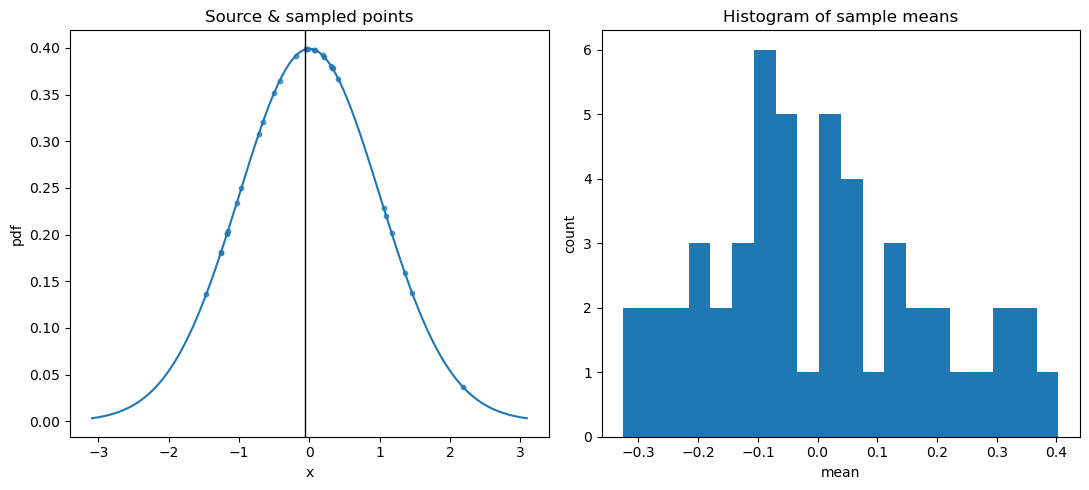

In [18]:
visualize_clt()

In [37]:
bufmeans

array([-2.79374026e-01,  1.32801469e-01, -1.72662242e-01, -2.85255593e-01,
        2.47308763e-01,  6.66043752e-02, -8.48574436e-02,  9.70646755e-02,
        1.50630633e-01,  1.15272461e-01,  5.34832457e-02,  1.61944529e-01,
       -1.62871588e-02, -1.27819058e-02, -1.57514480e-01,  2.54826160e-01,
        2.32944074e-02,  2.75305131e-01,  1.12119753e-01, -9.23966277e-02,
        6.56828909e-02, -1.11201616e-01, -1.89430239e-02, -1.99184144e-01,
        1.01636550e-01, -1.81651597e-01,  1.77163297e-01,  1.55117210e-01,
        3.29060965e-01,  3.57454791e-01, -1.05734567e-02, -8.06831067e-02,
       -3.53377918e-01, -1.09498460e-01,  9.71124431e-02,  1.61466878e-01,
        8.62119087e-03, -7.42841847e-02,  6.45943315e-02, -1.76978880e-01,
       -6.76288914e-02, -4.77062398e-02,  5.40071925e-02, -1.89528143e-02,
        9.19442556e-02,  6.17545973e-02,  7.13048136e-02,  5.21612596e-02,
       -6.36662797e-04, -2.02298029e-01,  2.55070293e-01,  1.06827727e-01,
        1.69537423e-02,  

In [38]:
means2=np.array([-2.79374026e-01,  1.32801469e-01, -1.72662242e-01, -2.85255593e-01,
        2.47308763e-01,  6.66043752e-02, -8.48574436e-02,  9.70646755e-02,
        1.50630633e-01,  1.15272461e-01,  5.34832457e-02,  1.61944529e-01,
       -1.62871588e-02, -1.27819058e-02, -1.57514480e-01,  2.54826160e-01,
        2.32944074e-02,  2.75305131e-01,  1.12119753e-01, -9.23966277e-02,
        6.56828909e-02, -1.11201616e-01, -1.89430239e-02, -1.99184144e-01,
        1.01636550e-01, -1.81651597e-01,  1.77163297e-01,  1.55117210e-01,
        3.29060965e-01,  3.57454791e-01, -1.05734567e-02, -8.06831067e-02,
       -3.53377918e-01, -1.09498460e-01,  9.71124431e-02,  1.61466878e-01,
        8.62119087e-03, -7.42841847e-02,  6.45943315e-02, -1.76978880e-01,
       -6.76288914e-02, -4.77062398e-02,  5.40071925e-02, -1.89528143e-02,
        9.19442556e-02,  6.17545973e-02,  7.13048136e-02,  5.21612596e-02,
       -6.36662797e-04, -2.02298029e-01,  2.55070293e-01,  1.06827727e-01,
        1.69537423e-02,  3.06013447e-01, -9.51423428e-02, -1.51675117e-01,
       -6.81577224e-02, -2.16632507e-02, -1.29303988e-01,  1.19607896e-01,
        1.52032018e-01, -2.74462379e-02, -1.01317868e-02, -1.76385204e-01,
        3.84880342e-01,  3.18068256e-01, -1.40823047e-01, -2.55351016e-01,
       -2.33329666e-01, -1.32384193e-01, -2.41464392e-01,  2.64225342e-01,
        1.72672474e-01,  1.94167711e-01, -9.44899530e-02,  1.21134396e-01,
        3.02848134e-01,  2.63267101e-01,  2.24873883e-01,  1.48673156e-01,
        5.96851085e-03,  1.30261087e-01, -1.05616922e-01,  9.73116860e-02,
       -1.83345630e-01, -3.25271986e-01, -2.45309667e-02,  5.99061034e-02,
       -7.14337110e-02,  1.95963357e-02,  3.08766138e-01,  5.63157721e-02,
       -6.34185666e-02,  1.59683004e-01,  9.82491963e-02,  2.23994979e-02,
       -5.77994993e-02,  7.52595435e-02, -7.78006738e-02, -1.29156504e-01,
       -1.45361714e-01, -1.79215177e-01,  2.99096803e-01,  3.97913080e-01,
        6.67364130e-02,  2.02530930e-01,  1.88251223e-01,  9.25564930e-02,
        1.53271481e-01, -2.51655777e-01,  1.43578432e-01, -6.30084945e-02,
        1.14723336e-01, -1.64836043e-02,  2.12645073e-01, -9.95666454e-02,
       -1.98823626e-01,  1.06218851e-01, -9.58586609e-02,  2.00682893e-02,
        3.46398506e-02,  6.18930030e-02, -6.83695702e-02, -1.13577658e-01,
       -1.05018778e-02, -6.55013681e-02, -6.19179093e-02,  3.05572928e-01,
        8.04388017e-02, -2.05020487e-01, -2.09994784e-01, -3.34143128e-02,
        5.00052046e-02, -1.23983292e-01, -6.36222787e-02,  1.46471698e-02,
       -7.95416573e-02,  1.39794155e-02,  8.23956280e-02,  1.83125399e-01,
       -1.44019335e-02, -1.59515860e-02,  2.84034634e-01, -2.21045739e-01,
       -1.51533447e-01,  3.21834068e-01,  2.55504036e-01, -2.85851209e-03,
       -6.21317240e-02,  6.64439630e-02, -2.81291275e-02, -7.70563080e-02,
       -1.60780956e-04, -1.81437627e-01,  3.15323585e-02,  4.75085951e-02,
        2.27555563e-01, -3.17406443e-01,  6.15860453e-02,  2.08797803e-01])


In [11]:
if __name__ == "__main__":
    # Minimal demo run (why: reproducible smoke test)
    list_distributions()
    # Uncomment for a quick CLI run (Jupyter recommended):
    # visualize_clt("uniform", x1=30, x2=20, dist_params={"loc": 0, "scale": 1}, pause_s=0.5, random_state=42)
    pass

Choose from following available continuous distributions:
 - beta
 - cauchy
 - chi2
 - expon
 - gamma
 - laplace
 - lognorm
 - norm
 - pareto
 - t
 - uniform
 - weibull_max
 - weibull_min


In [ ]:
visualize_clt("uniform", x1=40, x2=50, pause_s=0.3,
                  dist_params={"loc":0, "scale":1},
                  capture_gif_path="clt.gif", capture_backend="mpl")

In [29]:
# some code to make plotly sub graphs, not used here

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Source distribution & sampled points", "Histogram of current sample's means"),
    specs=[[{"type": "xy"}, {"type": "xy"}]],
    horizontal_spacing=0.12,
)
_frames = [] if (capture_backend == "mpl" and capture_gif_path) else None  # store PNG frames if capture_gif_path is set
# Disable live Plotly updates under SSH when doing server-side capture
live_updates = False if (capture_backend == "mpl" and capture_gif_path) else True

# Left: PDF curve -- MAIN CURVE
fig.add_trace(
    go.Scatter(x=xgrid_pdf, y=ygrid_pdf, mode="lines", name=f"{distribution_name} pdf"),
    row=1, col=1
)
# Prepare chart traces for later dynamic updates with new sampled data in each iteration of the loop
fig.add_trace( # Sample points -- scatter -- CHANGES EVERY ITERATION
    go.Scatter(x=[], y=[], mode="markers", name="current samples"),
    row=1, col=1
)
fig.add_trace( # Mean -- vertical line -- CHANGES EVERY ITERATION
    go.Scatter(x=[], y=[], mode="lines", name="current mean",),
    row=1, col=1
)

# RIGHT -- Histogram bars -- APPENDS WITH NEW BARS EVERY ITERATION
#  re-draw bar trace every frame for stable heights, and hence keep it in a separate variable
hist_bar = go.Bar(x=[], y=[], name="histogram of sample means")
fig.add_trace(hist_bar, row=1, col=2)
# placeholder set of means (start empty)
means: list[float] = []

fig.update_layout(height=500, width=1100, title_text="Central Limit Theorem — iterative sampling")

In [31]:
#QUICK CHECK on ploytly image savedown - NOT REQUIRED EVERYTIME
import sys, pkgutil, platform,plotly

pio.defaults.chromium_executable = "/hpctmp/e1554287/conda/envs/ai1008/lib/python3.13/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome"
#Sanity check
print("Using:", pio.defaults.chromium_executable)

# Hardened flags for restricted environments (no GPU / no sandbox / shared mem)
pio.defaults.chromium_args = [
    "--headless=new",
    "--disable-gpu",
    "--no-sandbox",
    "--disable-dev-shm-usage",
    "--no-first-run",
    "--no-default-browser-check",
    "--disable-software-rasterizer",
]


print("Python exe:", sys.executable)
print("Platform:", platform.platform())
mods = {m: bool(pkgutil.find_loader(m)) for m in ["plotly", "kaleido"]}
print("Found:", mods)
print("plotly version:", plotly.__version__)
import kaleido, plotly, plotly.io as pio
print("kaleido:", getattr(kaleido, "__version__", "unknown"))
print("plotly:", plotly.__version__)
print("pio.kaleido.scope set:", pio.kaleido.scope is not None)

fig = go.Figure(data=[go.Scatter(y=[0,1,0])])
_ = fig.write_image("scatter_plot.png")  # returns bytes without error if kaleido is working
fig

# import plotly.express as px
# fig = px.scatter(px.data.iris(), x='sepal_width', y='sepal_length')
# fig.write_image("scatter_plot.png")

Python exe: /hpctmp/e1554287/conda/envs/ai1008/bin/python
Platform: Linux-3.10.0-1160.71.1.el7.x86_64-x86_64-with-glibc2.17
Found: {'plotly': True, 'kaleido': True}
plotly version: 6.3.0


/var/tmp/pbs.178281.venus01/ipykernel_10558/3904357896.py:4: DeprecationWarning:

'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead

